# EDA 작업 노트북 - Phase 6: zone B/C/D 잔여 불확실성 분해 (미래 net_load + 태양광 날씨)

- 목적: Phase 5 에서 `net_load` 는 floor(smp_rt<5) 위험의 *기울기*만 설명하고, 최악(zone D)도
  P~34% 가 상한 = **잔여 ~2/3 미설명**. 이를 ① **미래 net_load(lead/추세/forward-min)**
  ② **실시간 태양광 날씨** 로 분해한다. (leakage 무시 - 원인 규명용 EDA)
- 핵심 도구: 단순 상관 대신 **조건부 floor 확률** + **계절x시간 통제** + **zone내 분위**
  (Phase 5 의 명시적 재설계 요구). floor 정의 = `smp_rt < 5`.
- 구간: `clean_total` ⨝ `clean_rt_smp` = 2024-03-01 ~ 2026-05-13 (단일 레짐, 19,296h).
- 구성: Step 0 기준값검증 · 1 lead패밀리 · 2 미래vs현재 AUC · 3 zone내분위 P곡선 ·
  4 태양광날씨 · 5 lead+solar 결합 · 6 풍력=분산점검+야간 · 7 DA-RT gap · 8 종합/인계

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import matplotlib.font_manager as fm
import platform
from matplotlib import font_manager, rc

# 1. 마이너스 기호 깨짐 방지를 최상단에 먼저 설정
plt.rcParams['axes.unicode_minus'] = False

# 2. 운영체제에 따른 폰트 설정
if platform.system() == 'Windows':
    # 맑은 고딕을 인식할 수 있도록 시스템 이름과 영문 이름을 모두 리스트로 지정
    rc('font', family=['Malgun Gothic', 'sans-serif'])



# ── 데이터 로드 (eda5 와 동일 경로/인코딩) ───────────────────────
feat = pd.read_csv('clean_total.csv', index_col='timestamp', parse_dates=True, encoding='cp949')
rt   = pd.read_csv('clean_rt_smp.csv', index_col='timestamp', parse_dates=True)

df = feat.join(rt, how='inner').sort_index()      # 모델링 윈도 = 2024-03-01 ~ 2026-05-13

# 타깃 컬럼명 방어적 해석 (clean_rt_smp 버전에 따라 이름이 다를 수 있음)
TARGET = next((c for c in ('smp_rt_hourly_mean', 'smp_rt') if c in df.columns), None)
assert TARGET is not None, f'smp_rt 타깃 컬럼을 찾지 못함: {list(df.columns)}'

SEASON = {12:'겨울',1:'겨울',2:'겨울',3:'봄',4:'봄',5:'봄',
          6:'여름',7:'여름',8:'여름',9:'가을',10:'가을',11:'가을'}
SEASON_ORDER = ['봄','여름','가을','겨울']

def _daypart(h):
    if 2 <= h <= 5:   return '야간'
    if 6 <= h <= 9:   return '아침'
    if 10 <= h <= 13: return '한낮'
    if 14 <= h <= 17: return '오후'
    return '저녁'                                  # 18-23, 0-1

FLOOR = 5.0                                        # floor SMP 기준 (Phase 5 와 동일)

# ── 핵심 파생 변수 (Phase 5 규약) ───────────────────────────────
df['net_load']    = df['real_demand'] - df['real_renew_gen']
df['renew_share'] = (df['real_renew_gen'] / df['real_demand']).replace([np.inf,-np.inf], np.nan)
df['gap']         = df['smp_jeju'] - df[TARGET]    # DA - RT (Phase3 baseline 잔차)
df['rt_neg']      = df[TARGET]   < FLOOR           # RT floor
df['da_neg']      = df['smp_jeju'] < FLOOR         # DA floor
df['hour']        = df.index.hour
df['month']       = df.index.month
df['season']      = df['month'].map(SEASON)
df['daypart']     = df['hour'].map(_daypart)

# ── Phase 5 zone 경계 (eda5 Step 3 결과 그대로 고정) ────────────
NL_CUTS = [181.3, 264.5, 383.6]                    # D < 181.3 <= C < 264.5 <= B < 383.6 <= A
edges   = [-np.inf, NL_CUTS[0], NL_CUTS[1], NL_CUTS[2], np.inf]
df['zone'] = pd.cut(df['net_load'], bins=edges, labels=['D','C','B','A'])
ZONE_ORDER = ['A','B','C','D']
ZBCD = ['B','C','D']                               # Phase 6 관심 구간 (A=DA passthrough 해결)

# ── net_load lead / trajectory / forward-min 패밀리 ─────────────
# lead_h = t+h 의 net_load(미래) · delta_h = 미래-현재(추세, 음수=저점 진입) ·
# fwdmin_k = 향후 k시간 net_load 최저(다가오는 저점까지의 거리).
LEADS = [1, 2, 3, 4, 5, 6, 12, 24]
FWD   = [6, 12]
s_nl = df['net_load']
for h in LEADS:
    df[f'nl_lead_{h}']  = s_nl.shift(-h)
    df[f'nl_delta_{h}'] = df[f'nl_lead_{h}'] - s_nl
for k in FWD:
    df[f'nl_fwdmin_{k}'] = pd.concat([s_nl.shift(-i) for i in range(1, k+1)], axis=1).min(axis=1)

LEAD_VARS   = [f'nl_lead_{h}'  for h in LEADS]
DELTA_VARS  = [f'nl_delta_{h}' for h in LEADS]
FWD_VARS    = [f'nl_fwdmin_{k}' for k in FWD]
FUTURE_VARS = LEAD_VARS + DELTA_VARS + FWD_VARS

SOLAR_VARS = [c for c in ['solar_rad','total_cloud','midlow_cloud','Solar_Utilization'] if c in df.columns]

# ── 풍력: 외생(출력제어 전 자원량) vs 내생(출력제어 후 실현량) 구분 ──
#  도메인: KPX 는 대형 풍력을 출력제어(curtailment)한다 -> 실현 발전량은 *사후 결과*,
#  floor 압력의 진짜 원인은 *출력제어 전 풍속*. wind farms 는 제주 북부에 위치하므로
#  wind_spd_north 가 도메인상 정확한 외생 변수. real_wind_gen 은 Wind_Utilization 과
#  사실상 동의(중복) 이므로 제외.
EXO_WIND  = [c for c in ['wind_spd_north', 'wind_spd'] if c in df.columns]   # 출력제어 전 = 원인 후보
WIND_DIAG = [c for c in ['Wind_Utilization'] if c in df.columns]            # 출력제어 후 = 진단용
WIND_VARS = EXO_WIND + WIND_DIAG
BEST_WIND = next((c for c in ('wind_spd_north', 'wind_spd') if c in df.columns), None)

# ── 풍력터빈 운전영역 (풍속-출력 곡선 = 단조 아님, rated 구간 분리) ──
#  < 3 m/s     cutoff   : 컷인 미만 -> 발전 ~0 -> 과잉압력 없음
#  3 ~ 12 m/s  ramp     : 출력 ~v^3 상승 -> 출력제어 압력 상승
#  12 ~ 20 m/s rated    : 정격 출력(평탄·최대) -> 출력제어 압력 최대 -> P(floor) 정점 예상
#  >= 20 m/s   shutdown : 컷아웃 보호정지 -> 발전 급감 -> 압력 다시 하락
#  -> 3분위(저/중/고)는 단조 가정이라 rated<->shutdown 처럼 단조가 아닌 구간을 못 잡음.
WIND_CUT        = [3.0, 12.0, 20.0]                # 컷인 / 정격풍속 / 컷아웃 (도메인 입력, 실제 컷아웃 ~25)
WIND_REG_LABELS = ['cutoff(<3)', 'ramp(3-12)', 'rated(12-20)', 'shutdown(>=20)']
def wind_regime(s):
    return pd.cut(s, bins=[-np.inf] + WIND_CUT + [np.inf],
                  right=False, labels=WIND_REG_LABELS)
df['wind_reg'] = wind_regime(df[BEST_WIND]) if BEST_WIND else np.nan

# ── 공용 헬퍼 ───────────────────────────────────────────────────
def mw_auc(col, y):
    # Mann-Whitney 순위 AUC. >0.5 = 값 클수록 floor. 반환 (auc, n)
    m = col.notna() & y.notna()
    x, yy = col[m], y[m].astype(int)
    if yy.nunique() < 2 or len(x) < 30:
        return np.nan, int(len(x))
    r = x.rank(method='average')
    npos = int(yy.sum()); nneg = len(x) - npos
    a = (r[yy == 1].sum() - npos*(npos+1)/2) / (npos*nneg)
    return float(a), int(len(x))

def sep(a):
    # 방향 무관 분리력: 0=무신호, 1=완전분리
    return np.nan if pd.isna(a) else abs(a - 0.5) * 2

def controlled_sep(frame, col, ycol='rt_neg', min_n=40):
    # 계절 x daypart 셀 내부 분리력의 표본가중 평균 (계절x시간 교란 통제)
    accs, ws = [], []
    for _, g in frame.groupby(['season','daypart'], observed=True):
        d = sep(mw_auc(g[col], g[ycol])[0])
        n = int(g[col].notna().sum())
        if not pd.isna(d) and n >= min_n:
            accs.append(d); ws.append(n)
    return float(np.average(accs, weights=ws)) if accs else np.nan

def zone_quantile(frame, col, q):
    # zone 내부 분위(qcut). 전역분위가 zone 안에서 붕괴(Phase5)하는 문제 회피
    out = pd.Series(index=frame.index, dtype='float')
    for z in ZBCD:
        idx = frame.index[frame['zone'] == z]
        v = frame.loc[idx, col].replace([np.inf,-np.inf], np.nan).dropna()
        if len(v) >= q*10:
            out.loc[v.index] = pd.qcut(v.rank(method='first'), q, labels=False).values
    return out

def zone_tercile(frame, col):
    # zone 내부 3분위 라벨(저/중/고)
    out = pd.Series(index=frame.index, dtype='object')
    for z in ZBCD:
        idx = frame.index[frame['zone'] == z]
        v = frame.loc[idx, col].replace([np.inf,-np.inf], np.nan).dropna()
        if len(v) >= 30:
            out.loc[v.index] = pd.qcut(v.rank(method='first'), 3,
                                       labels=['저','중','고']).astype(object).values
    return out

def eta2(frame, gcols, ycol='rt_neg'):
    # 이진 결과 상관비 eta^2 = 그룹간 분산 / 전체 베르누이 분산 (설명된 비율)
    s = frame.dropna(subset=list(gcols)+[ycol])
    if len(s) == 0:
        return np.nan
    p, N = s[ycol].mean(), len(s)
    tot = p*(1-p)
    if tot == 0:
        return np.nan
    bet = sum(len(g)/N * (g[ycol].mean()-p)**2
              for _, g in s.groupby(list(gcols), observed=True))
    return bet/tot

print('Phase 6 셋업 완료')
print(f'  df          : {df.shape}  ({df.index.min().date()} ~ {df.index.max().date()})')
print(f'  TARGET      : {TARGET}   (floor = {TARGET} < {FLOOR})')
print(f'  future vars : {len(FUTURE_VARS)}개 (lead {LEADS} + delta + fwdmin {FWD})')
print(f'  solar       : {SOLAR_VARS}')
print(f'  wind 외생/내생: {EXO_WIND} / {WIND_DIAG}   (BEST_WIND={BEST_WIND})')
print(f'  wind 운전영역 ({BEST_WIND}, 컷 {WIND_CUT} m/s):')
print('   ', dict(df['wind_reg'].value_counts().reindex(WIND_REG_LABELS)))

Phase 6 셋업 완료
  df          : (19296, 70)  (2024-03-01 ~ 2026-05-13)
  TARGET      : smp_rt_hourly_mean   (floor = smp_rt_hourly_mean < 5.0)
  future vars : 18개 (lead [1, 2, 3, 4, 5, 6, 12, 24] + delta + fwdmin [6, 12])
  solar       : ['solar_rad', 'total_cloud', 'midlow_cloud', 'Solar_Utilization']
  wind 외생/내생: ['wind_spd_north', 'wind_spd'] / ['Wind_Utilization']   (BEST_WIND=wind_spd_north)
  wind 운전영역 (wind_spd_north, 컷 [3.0, 12.0, 20.0] m/s):
    {'cutoff(<3)': 7856, 'ramp(3-12)': 11208, 'rated(12-20)': 232, 'shutdown(>=20)': 0}


## Step 0 - 셋업 검증 / Phase 5 기준값 일치 점검

**목표**: Phase 6 의 모든 분석이 Phase 5 와 동일한 윈도·zone 경계·floor 정의 위에서 도는지
먼저 증명한다. zone 별 표본비중·P(rt<5)·P(da<5) 를 Phase 5 digest 값과 대조해 PASS/FAIL.

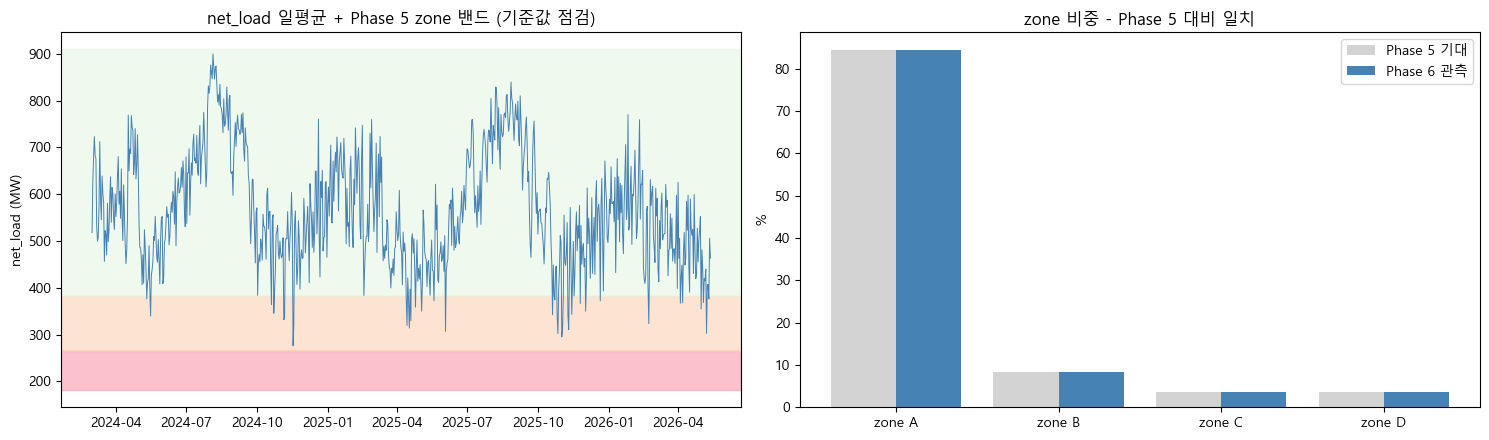

[Step 0] Phase 5 기준값 일치 점검
[관측 (Phase 6)]
          n  share_%  P_rt%  P_da%
zone                              
A     16295    84.45   0.47   0.10
B      1598     8.28   8.01   3.38
C       703     3.64  24.32  10.95
D       700     3.63  34.14  23.57

[기대 (Phase 5 digest)]
   share_%  P_rt%  P_da%
A    84.45   0.47   0.10
B     8.28   8.01   3.38
C     3.64  24.32  10.95
D     3.63  34.14  23.57

[절대편차]
      share_%  P_rt%  P_da%
zone                       
A         0.0    0.0    0.0
B         0.0    0.0    0.0
C         0.0    0.0    0.0
D         0.0    0.0    0.0

-> 판정: PASS - 동일 윈도/경계 재현 확인
   floor = smp_rt_hourly_mean < 5.0, 윈도 2024-03-01 ~ 2026-05-13 (19296행)
   관심 = zone B/C/D = 전체의 15.6% (A 84% 는 DA passthrough 로 해결)


In [2]:
# Phase 5 digest 기대값 (report.ipynb Phase 5 / eda5 Step 5 출력)
EXP = pd.DataFrame({'share_%':[84.45,8.28,3.64,3.63],
                    'P_rt%'  :[0.47, 8.01,24.32,34.14],
                    'P_da%'  :[0.10, 3.38,10.95,23.57]}, index=ZONE_ORDER)

g = df.groupby('zone', observed=False)
obs = pd.DataFrame({'n':g.size(),
                    'share_%':g.size()/len(df)*100,
                    'P_rt%' :g['rt_neg'].mean()*100,
                    'P_da%' :g['da_neg'].mean()*100}).reindex(ZONE_ORDER).round(2)

fig, ax = plt.subplots(1, 2, figsize=(15, 4.5))
nl_d = df['net_load'].resample('D').mean()
ax[0].plot(nl_d.index, nl_d.values, color='steelblue', lw=0.7)
prev = nl_d.min() - 10
for hi, lab, cband in zip(NL_CUTS + [nl_d.max()+10], ['D','C','B','A'],
                          ['#fde0dd','#fa9fb5','#fdcdac','#e5f5e0']):
    ax[0].axhspan(prev, hi, color=cband, alpha=0.55); prev = hi
ax[0].set_title('net_load 일평균 + Phase 5 zone 밴드 (기준값 점검)')
ax[0].set_ylabel('net_load (MW)')

x = np.arange(4)
ax[1].bar(x-0.2, EXP['share_%'].values, 0.4, color='lightgray', label='Phase 5 기대')
ax[1].bar(x+0.2, obs['share_%'].values, 0.4, color='steelblue', label='Phase 6 관측')
ax[1].set_xticks(x); ax[1].set_xticklabels([f'zone {z}' for z in ZONE_ORDER])
ax[1].set_title('zone 비중 - Phase 5 대비 일치'); ax[1].set_ylabel('%'); ax[1].legend()
plt.tight_layout(); plt.show()

dev = (obs[['share_%','P_rt%','P_da%']] - EXP).abs()
ok = bool((dev['share_%'] < 0.3).all() and (dev['P_rt%'] < 1.0).all())
print('='*64)
print('[Step 0] Phase 5 기준값 일치 점검')
print('='*64)
print('[관측 (Phase 6)]'); print(obs.to_string()); print()
print('[기대 (Phase 5 digest)]'); print(EXP.round(2).to_string()); print()
print('[절대편차]'); print(dev.round(2).to_string()); print()
print(f'-> 판정: {"PASS - 동일 윈도/경계 재현 확인" if ok else "FAIL - 불일치, 확인 필요"}')
print(f'   floor = {TARGET} < {FLOOR}, 윈도 {df.index.min().date()} ~ {df.index.max().date()} ({len(df)}행)')
print(f'   관심 = zone B/C/D = 전체의 {obs.loc[ZBCD,"share_%"].sum():.1f}% (A 84% 는 DA passthrough 로 해결)')

## Step 1 - 미래 net_load 패밀리 생성 / 점검

**목표**: `nl_lead_h`(미래값)·`nl_delta_h`(추세)·`nl_fwdmin_k`(다가오는 저점) 의 분포·결측을
점검하고, 미래 net_load 가 *다가오는 태양광 저점*을 현재 시점에 미리 보여줌을 샘플로 시각화.

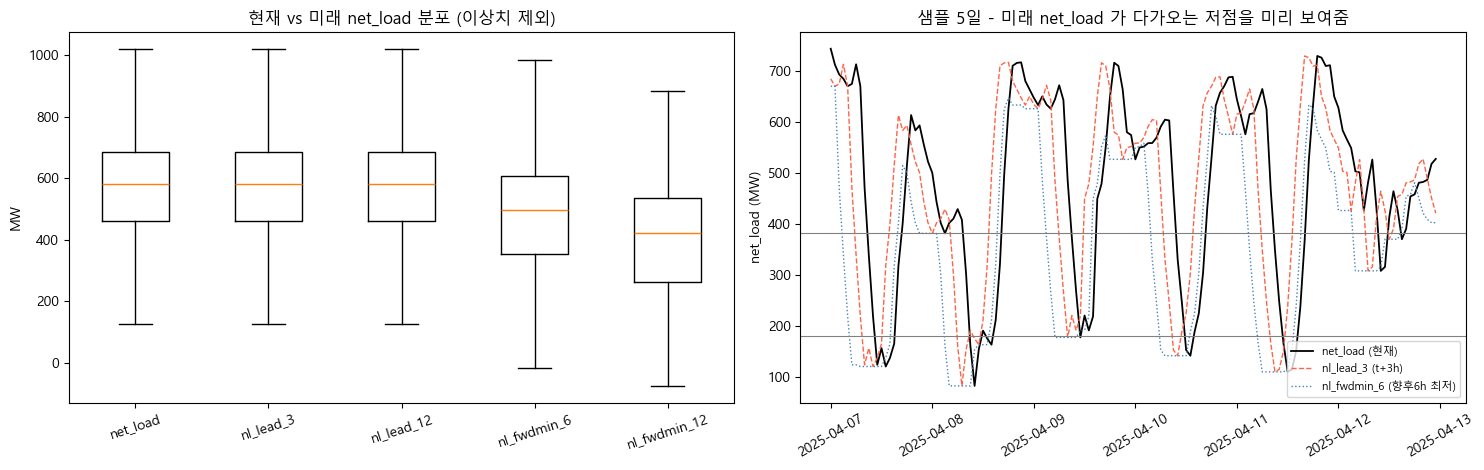

[Step 1] lead / trajectory / fwdmin 패밀리 점검
              NaN수     평균    std
nl_lead_1        1  566.7  187.4
nl_lead_2        2  566.7  187.4
nl_lead_3        3  566.7  187.4
nl_lead_4        4  566.7  187.4
nl_lead_5        5  566.7  187.4
nl_lead_6        6  566.7  187.5
nl_lead_12      12  566.7  187.5
nl_lead_24      24  566.7  187.5
nl_delta_1       1    0.0   64.3
nl_delta_2       2    0.0  110.4
nl_delta_3       3    0.0  149.4
nl_delta_4       4    0.0  181.4
nl_delta_5       5    0.0  206.1
nl_delta_6       6    0.0  224.4
nl_delta_12     12   -0.0  247.5
nl_delta_24     24   -0.1  132.7
nl_fwdmin_6      1  471.6  185.6
nl_fwdmin_12     1  398.7  180.6

-> 꼬리 NaN 은 시계열 끝(최대 24행)에서만 발생, 이후 분석은 dropna 처리.
   delta<0 = 다가오는 저점으로 하강(태양광 램프 진입), fwdmin = 곧 닥칠 최저 net_load.


In [3]:
fig, ax = plt.subplots(1, 2, figsize=(15, 4.8))
show = ['net_load','nl_lead_3','nl_lead_12','nl_fwdmin_6','nl_fwdmin_12']
ax[0].boxplot([df[c].dropna() for c in show], labels=show, showfliers=False)
ax[0].set_title('현재 vs 미래 net_load 분포 (이상치 제외)')
ax[0].set_ylabel('MW'); ax[0].tick_params(axis='x', rotation=18)

sl = df.loc['2025-04-07':'2025-04-12']
ax[1].plot(sl.index, sl['net_load'],    color='black',     lw=1.3, label='net_load (현재)')
ax[1].plot(sl.index, sl['nl_lead_3'],   color='tomato',    lw=1.0, ls='--', label='nl_lead_3 (t+3h)')
ax[1].plot(sl.index, sl['nl_fwdmin_6'], color='steelblue', lw=1.0, ls=':',  label='nl_fwdmin_6 (향후6h 최저)')
ax[1].axhline(NL_CUTS[0], color='gray', lw=0.8); ax[1].axhline(NL_CUTS[2], color='gray', lw=0.8)
ax[1].set_title('샘플 5일 - 미래 net_load 가 다가오는 저점을 미리 보여줌')
ax[1].set_ylabel('net_load (MW)'); ax[1].legend(fontsize=8); ax[1].tick_params(axis='x', rotation=30)
plt.tight_layout(); plt.show()

cov = pd.DataFrame({'NaN수':[int(df[c].isna().sum()) for c in FUTURE_VARS],
                    '평균' :[round(df[c].mean(),1)   for c in FUTURE_VARS],
                    'std'  :[round(df[c].std(),1)    for c in FUTURE_VARS]}, index=FUTURE_VARS)
print('='*64)
print('[Step 1] lead / trajectory / fwdmin 패밀리 점검')
print('='*64)
print(cov.to_string()); print()
print(f'-> 꼬리 NaN 은 시계열 끝(최대 {max(LEADS)}행)에서만 발생, 이후 분석은 dropna 처리.')
print('   delta<0 = 다가오는 저점으로 하강(태양광 램프 진입), fwdmin = 곧 닥칠 최저 net_load.')

## Step 2 - 미래 net_load vs 현재 net_load : floor 판별력(AUC)

**목표**: 각 미래변수/현재 net_load 의 floor(rt<5) 단일변수 분리력을 ① 전체 ② zone B/C/D
③ B/C/D + **계절x시간 통제** 세 조건으로 비교. *미래 net_load 가 현재를 이기는가, 어느 horizon 인가.*

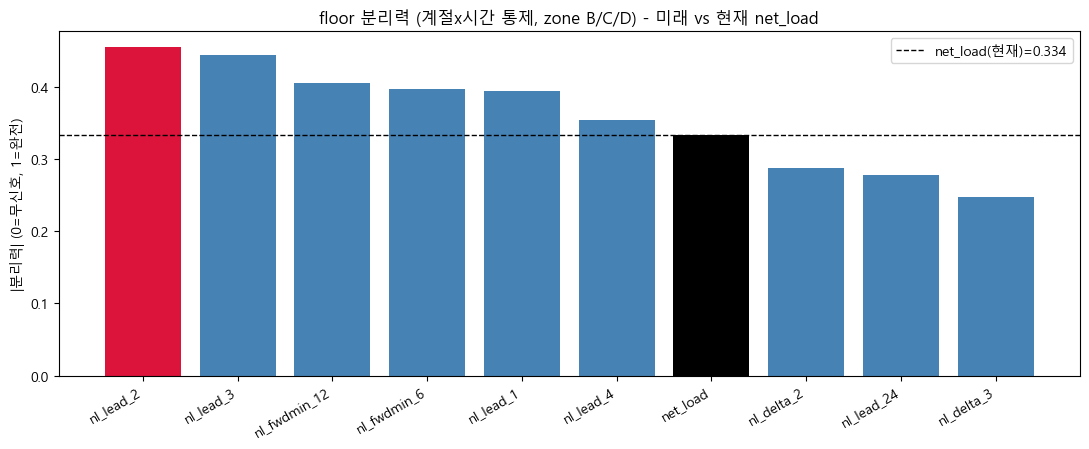

[Step 2] 미래 net_load vs 현재 - floor 판별력 (sep_BCD_ctrl 내림차순)
              auc_all  sep_all  sep_BCD  sep_BCD_ctrl  n_BCD
var                                                         
nl_lead_2       0.071    0.858    0.531         0.455   3001
nl_lead_3       0.105    0.790    0.481         0.445   3001
nl_fwdmin_12    0.182    0.637    0.352         0.405   3001
nl_fwdmin_6     0.114    0.772    0.407         0.397   3001
nl_lead_1       0.062    0.876    0.498         0.394   3001
nl_lead_4       0.181    0.638    0.380         0.355   3001
net_load        0.065    0.870    0.430         0.334   3001
nl_delta_2      0.547    0.094    0.279         0.288   3001
nl_lead_24      0.140    0.720    0.339         0.278   2993
nl_delta_3      0.626    0.253    0.246         0.248   3001
nl_lead_5       0.296    0.408    0.240         0.245   3001
nl_delta_1      0.497    0.007    0.206         0.237   3001
nl_delta_12     0.906    0.813    0.442         0.236   2996
nl_lead_6       0.424    0

In [4]:
VARS = ['net_load'] + FUTURE_VARS
bcd  = df[df['zone'].isin(ZBCD)]
rows = []
for c in VARS:
    a_all = mw_auc(df[c],  df['rt_neg'])[0]
    a_bcd, n_bcd = mw_auc(bcd[c], bcd['rt_neg'])
    rows.append({'var':c,
                 'auc_all'     : round(a_all,3) if not pd.isna(a_all) else np.nan,
                 'sep_all'     : round(sep(a_all),3),
                 'sep_BCD'     : round(sep(a_bcd),3),
                 'sep_BCD_ctrl': round(controlled_sep(bcd, c),3),
                 'n_BCD'       : n_bcd})
S2 = pd.DataFrame(rows).set_index('var').sort_values('sep_BCD_ctrl', ascending=False)

cur      = S2.loc['net_load','sep_BCD_ctrl']
fut      = S2.drop(index='net_load')
BEST_FUT = fut['sep_BCD_ctrl'].idxmax()            # 후속 스텝의 대표 미래변수
best_val = S2.loc[BEST_FUT,'sep_BCD_ctrl']

top = S2.head(10)
fig, ax = plt.subplots(figsize=(11, 4.6))
cols = ['crimson' if i==BEST_FUT else ('black' if i=='net_load' else 'steelblue') for i in top.index]
ax.bar(range(len(top)), top['sep_BCD_ctrl'].values, color=cols)
ax.set_xticks(range(len(top))); ax.set_xticklabels(top.index, rotation=30, ha='right')
ax.axhline(cur, color='black', ls='--', lw=1, label=f'net_load(현재)={cur:.3f}')
ax.set_title('floor 분리력 (계절x시간 통제, zone B/C/D) - 미래 vs 현재 net_load')
ax.set_ylabel('|분리력| (0=무신호, 1=완전)'); ax.legend()
plt.tight_layout(); plt.show()

print('='*64)
print('[Step 2] 미래 net_load vs 현재 - floor 판별력 (sep_BCD_ctrl 내림차순)')
print('='*64)
print(S2.to_string()); print()
print(f'현재 net_load 통제분리력 = {cur:.3f}')
print(f'최고 미래변수 = {BEST_FUT}  통제분리력 = {best_val:.3f}  (현재 대비 {best_val-cur:+.3f})')
print('-> ' + ('미래 net_load 가 현재보다 우수 = 가설 지지' if best_val > cur + 0.01
                else '미래가 현재를 못 넘음 = 가설 약함')
      + '. sep_BCD vs sep_BCD_ctrl 로 통제 후 잔존 여부 확인.')

## Step 3 - zone내 분위별 floor 확률 : 대표 미래변수 vs 현재 net_load

**목표**: Step 2 가 고른 `BEST_FUT` 와 `net_load` 를 **zone 내부 6분위**로 끊어 P(smp_rt<5)
곡선을 그린다. 미래변수 곡선이 더 가파르면 zone(net_load) *내부*에 추가 신호가 있다는 뜻.

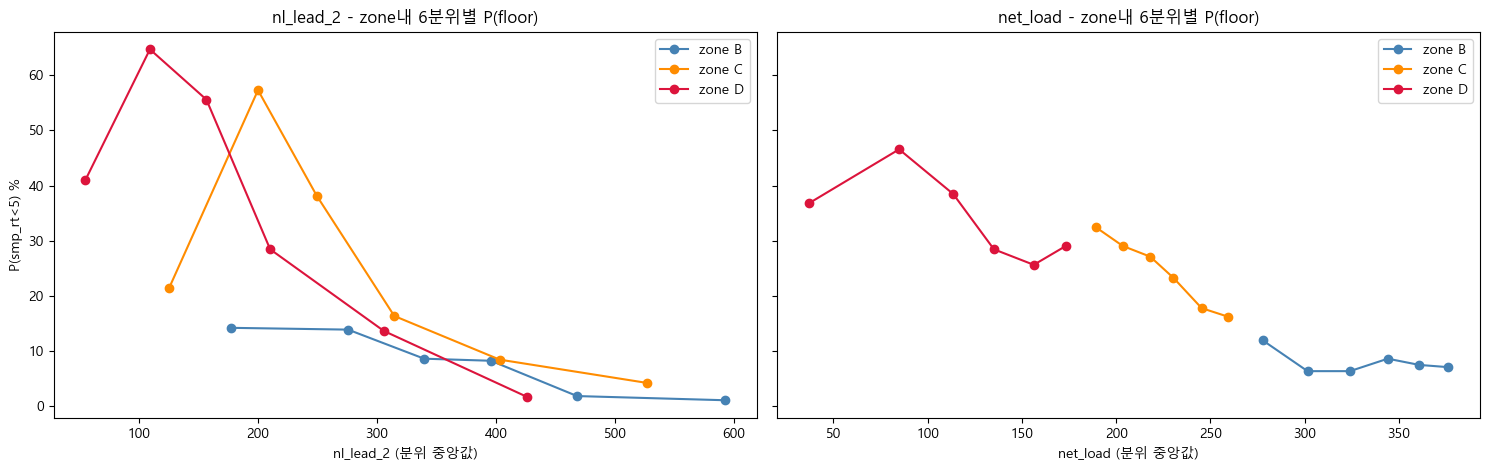

[Step 3] zone내 분위별 floor 확률 - 대표 미래변수 vs 현재 net_load
[nl_lead_2]
  zone B: P 14.2% -> 1.1%  (스윙 -13.1%p)
  zone C: P 21.4% -> 4.3%  (스윙 -17.1%p)
  zone D: P 41.0% -> 1.7%  (스윙 -39.3%p)

[net_load]
  zone B: P 12.0% -> 7.1%  (스윙 -4.9%p)
  zone C: P 32.5% -> 16.2%  (스윙 -16.2%p)
  zone D: P 36.8% -> 29.1%  (스윙 -7.7%p)

-> 미래변수 스윙폭 > net_load 스윙폭 이면 zone 내부에서 추가 floor 신호 보유.


In [5]:
Q = 6
for col in [BEST_FUT, 'net_load']:
    df[f'_qz_{col}'] = zone_quantile(df, col, Q)

fig, ax = plt.subplots(1, 2, figsize=(15, 4.8), sharey=True)
for j, col in enumerate([BEST_FUT, 'net_load']):
    qz = f'_qz_{col}'
    for z, cc in zip(ZBCD, ['steelblue','darkorange','crimson']):
        sub = df[(df['zone']==z) & df[qz].notna()]
        gg  = sub.groupby(qz)
        ax[j].plot(gg[col].median().values, gg['rt_neg'].mean().values*100,
                   'o-', color=cc, label=f'zone {z}')
    ax[j].set_title(f'{col} - zone내 {Q}분위별 P(floor)')
    ax[j].set_xlabel(f'{col} (분위 중앙값)'); ax[j].legend()
ax[0].set_ylabel('P(smp_rt<5) %')
plt.tight_layout(); plt.show()

print('='*64)
print('[Step 3] zone내 분위별 floor 확률 - 대표 미래변수 vs 현재 net_load')
print('='*64)
for col in [BEST_FUT, 'net_load']:
    qz = f'_qz_{col}'
    print(f'[{col}]')
    for z in ZBCD:
        gg = df[(df['zone']==z) & df[qz].notna()].groupby(qz)['rt_neg'].mean()*100
        if len(gg):
            print(f'  zone {z}: P {gg.iloc[0]:.1f}% -> {gg.iloc[-1]:.1f}%  '
                  f'(스윙 {gg.iloc[-1]-gg.iloc[0]:+.1f}%p)')
    print()
print('-> 미래변수 스윙폭 > net_load 스윙폭 이면 zone 내부에서 추가 floor 신호 보유.')

## Step 4 - 태양광 날씨 분해 (원래 Phase 6 코어)

**목표**: `solar_rad`/`total_cloud`/`midlow_cloud`/`Solar_Utilization` 의 floor 분리력을
net_load·대표 미래변수와 나란히 비교(계절x시간 통제). Phase 5("floor=태양광 현상") 재확인 +
가장 강한 태양광 변수의 zone내 분위 P곡선.

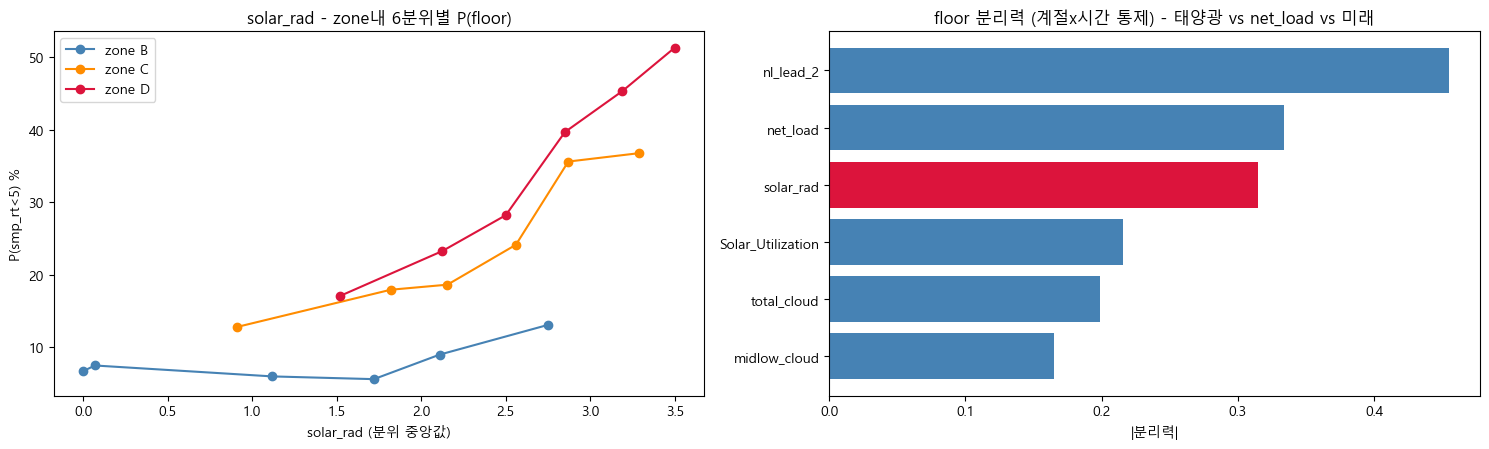

[Step 4] 태양광 날씨 vs net_load vs 미래 net_load
                   auc_BCD  sep_BCD  sep_BCD_ctrl     n
var                                                    
nl_lead_2            0.235    0.531         0.455  3001
net_load             0.285    0.430         0.334  3001
solar_rad            0.709    0.418         0.315  3001
Solar_Utilization    0.676    0.352         0.216  3001
total_cloud          0.386    0.229         0.199  3001
midlow_cloud         0.383    0.235         0.165  3001

-> 최강 태양광 변수 = solar_rad (sep_ctrl=0.315).
   태양광 변수가 net_load 수준의 분리력을 통제 후에도 유지하면 = floor 는 태양광 현상(Phase5 재확인),
   미래 net_load 와 분리력이 다르면 = 서로 다른 축(결합 가치) -> Step 5.


In [6]:
cmp_vars = SOLAR_VARS + ['net_load', BEST_FUT]
rows = []
for c in cmp_vars:
    a, n = mw_auc(bcd[c], bcd['rt_neg'])
    rows.append({'var':c, 'auc_BCD':round(a,3), 'sep_BCD':round(sep(a),3),
                 'sep_BCD_ctrl':round(controlled_sep(bcd, c),3), 'n':n})
S4 = pd.DataFrame(rows).set_index('var').sort_values('sep_BCD_ctrl', ascending=False)
BEST_SOLAR = next(v for v in S4.index if v in SOLAR_VARS)

df[f'_qz_{BEST_SOLAR}'] = zone_quantile(df, BEST_SOLAR, 6)
fig, ax = plt.subplots(1, 2, figsize=(15, 4.6))
qz = f'_qz_{BEST_SOLAR}'
for z, cc in zip(ZBCD, ['steelblue','darkorange','crimson']):
    sub = df[(df['zone']==z) & df[qz].notna()]
    gg  = sub.groupby(qz)
    ax[0].plot(gg[BEST_SOLAR].median().values, gg['rt_neg'].mean().values*100,
               'o-', color=cc, label=f'zone {z}')
ax[0].set_title(f'{BEST_SOLAR} - zone내 6분위별 P(floor)')
ax[0].set_xlabel(f'{BEST_SOLAR} (분위 중앙값)'); ax[0].set_ylabel('P(smp_rt<5) %'); ax[0].legend()

S4s = S4.sort_values('sep_BCD_ctrl')
ax[1].barh(range(len(S4s)), S4s['sep_BCD_ctrl'].values,
           color=['crimson' if i==BEST_SOLAR else 'steelblue' for i in S4s.index])
ax[1].set_yticks(range(len(S4s))); ax[1].set_yticklabels(S4s.index)
ax[1].set_title('floor 분리력 (계절x시간 통제) - 태양광 vs net_load vs 미래')
ax[1].set_xlabel('|분리력|')
plt.tight_layout(); plt.show()

print('='*64)
print('[Step 4] 태양광 날씨 vs net_load vs 미래 net_load')
print('='*64)
print(S4.to_string()); print()
print(f'-> 최강 태양광 변수 = {BEST_SOLAR} (sep_ctrl={S4.loc[BEST_SOLAR,"sep_BCD_ctrl"]:.3f}).')
print('   태양광 변수가 net_load 수준의 분리력을 통제 후에도 유지하면 = floor 는 태양광 현상(Phase5 재확인),')
print('   미래 net_load 와 분리력이 다르면 = 서로 다른 축(결합 가치) -> Step 5.')

## Step 5 - 미래 net_load + 태양광 + 외생 풍력 결합 : Phase 5 잔여 ~2/3 추가 설명?

**목표**: zone(net_load) 만의 floor 분산을 기준선으로, **zone내 3분위**를 ① 미래변수
② 태양광 ③ **외생 풍력**(`wind_spd_north` = 출력제어 *전* 북부 자원량) 순으로 더하며
eta^2 증분을 분해한다. 풍력은 KPX 가 대형 풍력을 출력제어하므로 *실현 발전량*이 아니라
*북부 풍속*이 진짜 압력 축 -> 태양광과 별개의 세 번째 축으로 포함. 3x3 P 행렬(미래 x 태양광)로
"같은 zone 안에서도 가른다"를 시각화하고, 풍력 증분은 eta^2 사다리에서 별도 확인.

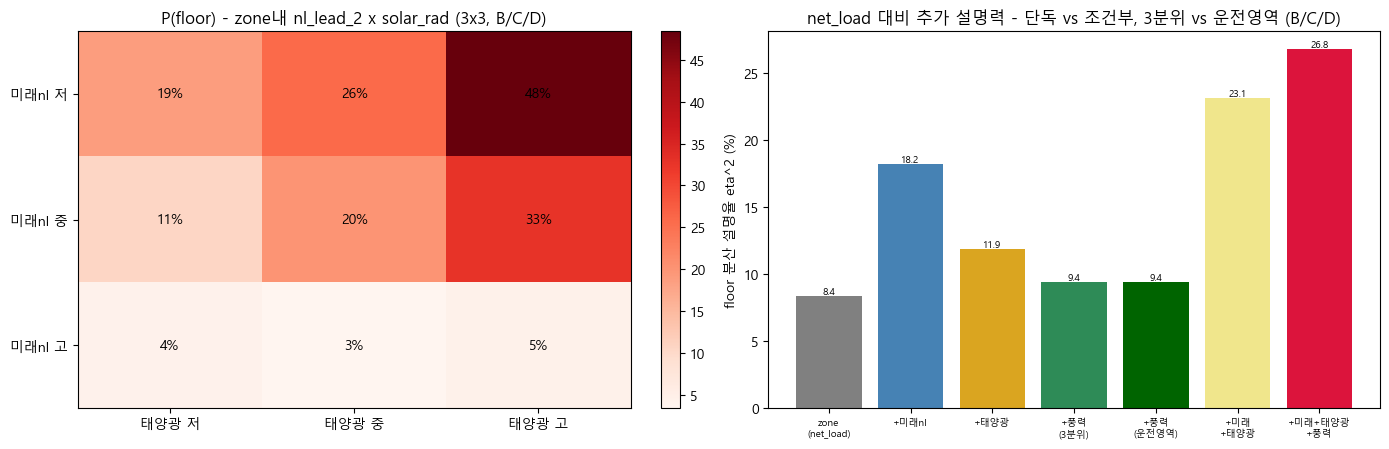

[Step 5] 미래 net_load + 태양광 + 외생 풍력 결합 설명력 (zone B/C/D)
  zone(net_load)             eta^2 =   8.4%
  + 미래 net_load 3분위      eta^2 =  18.2%  (+9.8%p)
  + 태양광 3분위             eta^2 =  11.9%  (+3.5%p)
  + 미래+태양광              eta^2 =  23.1%  (풍력 조건부 기준선)
  + 미래+태양광+풍력(3분위)  eta^2 =  26.8%  (+3.6%p)
  + 미래+태양광+풍력(운전영역) eta^2 =  25.8%  (+2.7%p)

-> 풍력 결합 후 최고 = 3분위(단조) (eta^2 26.8%, 잔여의 20.1% 추가 설명).
   [풍력 그룹화]  단독  3분위 +1.0%p / 운전영역 +1.1%p   조건부  3분위 +3.6%p / 운전영역 +2.7%p
   운전영역이 3분위를 못 넘으면 = 본 풍속변수로는 터빈 단조 아님(rated/shutdown) 관측
   불가 -> 풍력은 zone내 단조(고풍=floor↑) 신호로 채택.
   조건부 >> 단독 = 출력제어에 가려진 억제변수가 맥락 통제 후 드러남 = 별개 floor 축(유효).


In [7]:
b2 = df[df['zone'].isin(ZBCD)].copy()
b2['lead_t']   = zone_tercile(b2, BEST_FUT)
b2['solar_t']  = zone_tercile(b2, BEST_SOLAR)
b2['wind_t']   = zone_tercile(b2, BEST_WIND)               # 데이터 3분위 (단조)
b2['wind_reg'] = df.loc[b2.index, 'wind_reg']              # 물리 운전영역 (단조 아님 가설)

e_zone   = eta2(b2, ['zone'])
e_lead   = eta2(b2, ['zone','lead_t'])
e_solar  = eta2(b2, ['zone','solar_t'])
e_wind   = eta2(b2, ['zone','wind_t'])                     # 풍력=3분위
e_wreg   = eta2(b2, ['zone','wind_reg'])                   # 풍력=운전영역
e_fs     = eta2(b2, ['zone','lead_t','solar_t'])           # 미래+태양광 = 풍력 조건부 기준선
e_all    = eta2(b2, ['zone','lead_t','solar_t','wind_t'])  # +풍력(3분위)
e_allreg = eta2(b2, ['zone','lead_t','solar_t','wind_reg'])# +풍력(운전영역)

TORD = ['저','중','고']
M = (b2.pivot_table(index='lead_t', columns='solar_t', values='rt_neg',
                     aggfunc='mean', observed=True)
       .reindex(index=TORD, columns=TORD) * 100)

fig, ax = plt.subplots(1, 2, figsize=(14, 4.6))
im = ax[0].imshow(M.values, cmap='Reds', aspect='auto')
ax[0].set_xticks(range(3)); ax[0].set_xticklabels([f'태양광 {c}' for c in TORD])
ax[0].set_yticks(range(3)); ax[0].set_yticklabels([f'미래nl {r}' for r in TORD])
for i in range(3):
    for k in range(3):
        v = M.values[i, k]
        ax[0].text(k, i, f'{v:.0f}%' if pd.notna(v) else '-', ha='center', va='center')
ax[0].set_title(f'P(floor) - zone내 {BEST_FUT} x {BEST_SOLAR} (3x3, B/C/D)')
fig.colorbar(im, ax=ax[0], fraction=0.046)

steps = ['zone\n(net_load)','+미래nl','+태양광','+풍력\n(3분위)','+풍력\n(운전영역)','+미래\n+태양광','+미래+태양광\n+풍력']
vals  = [e_zone, e_lead, e_solar, e_wind, e_wreg, e_fs, max(e_all, e_allreg)]
ax[1].bar(range(len(vals)), [v*100 for v in vals],
          color=['gray','steelblue','goldenrod','seagreen','darkgreen','khaki','crimson'])
ax[1].set_xticks(range(len(vals))); ax[1].set_xticklabels(steps, fontsize=7)
ax[1].set_ylabel('floor 분산 설명율 eta^2 (%)')
ax[1].set_title('net_load 대비 추가 설명력 - 단독 vs 조건부, 3분위 vs 운전영역 (B/C/D)')
for i, v in enumerate(vals):
    ax[1].text(i, v*100, f'{v*100:.1f}', ha='center', va='bottom', fontsize=7)
plt.tight_layout(); plt.show()

resid0   = 1 - e_zone
w_solo_t, w_solo_r = (e_wind-e_zone)*100, (e_wreg-e_zone)*100
w_cond_t, w_cond_r = (e_all-e_fs)*100,    (e_allreg-e_fs)*100
best_e   = max(e_all, e_allreg)
best_grp = '3분위(단조)' if e_all >= e_allreg else '운전영역(단조 아님)'
recov_b  = (best_e - e_zone) / resid0 * 100 if resid0 > 0 else np.nan
print('='*64)
print('[Step 5] 미래 net_load + 태양광 + 외생 풍력 결합 설명력 (zone B/C/D)')
print('='*64)
print(f'  zone(net_load)             eta^2 = {e_zone*100:5.1f}%')
print(f'  + 미래 net_load 3분위      eta^2 = {e_lead*100:5.1f}%  ({(e_lead-e_zone)*100:+.1f}%p)')
print(f'  + 태양광 3분위             eta^2 = {e_solar*100:5.1f}%  ({(e_solar-e_zone)*100:+.1f}%p)')
print(f'  + 미래+태양광              eta^2 = {e_fs*100:5.1f}%  (풍력 조건부 기준선)')
print(f'  + 미래+태양광+풍력(3분위)  eta^2 = {e_all*100:5.1f}%  ({(e_all-e_fs)*100:+.1f}%p)')
print(f'  + 미래+태양광+풍력(운전영역) eta^2 = {e_allreg*100:5.1f}%  ({(e_allreg-e_fs)*100:+.1f}%p)')
print()
print(f'-> 풍력 결합 후 최고 = {best_grp} (eta^2 {best_e*100:.1f}%, 잔여의 {recov_b:.1f}% 추가 설명).')
print(f'   [풍력 그룹화]  단독  3분위 {w_solo_t:+.1f}%p / 운전영역 {w_solo_r:+.1f}%p   '
      f'조건부  3분위 {w_cond_t:+.1f}%p / 운전영역 {w_cond_r:+.1f}%p')
print('   운전영역이 3분위를 못 넘으면 = 본 풍속변수로는 터빈 단조 아님(rated/shutdown) 관측')
print('   불가 -> 풍력은 zone내 단조(고풍=floor↑) 신호로 채택.')
print('   조건부 >> 단독 = 출력제어에 가려진 억제변수가 맥락 통제 후 드러남 = 별개 floor 축(유효).')

## Step 6 - 풍력 = floor 출력제어(curtailment) 압력 축 : 외생 vs 내생 (+ 운전영역 검증)

**목표**: 풍력을 ① **외생**(`wind_spd_north`/`wind_spd` = 출력제어 *전* 자원량)
② **내생**(`Wind_Utilization` = 출력제어 *후* 실현량) 으로 나눠 *반대 거동*(외생 강화·내생 붕괴)을
확인한다. 추가로 외생 풍속을 **풍력터빈 운전영역**(cutoff/ramp/rated/shutdown) 으로 끊어
P(floor) 가 *단조가 아닌지*(rated 정점·shutdown 하락) **가설을 검증**한다 — 단,
`wind_spd_north` 는 지표 평균 풍속이라 터빈 컷아웃(~20 m/s)에 거의 도달하지 않으므로
rated/shutdown 표본이 충분한지 함께 확인(부족하면 단조 아님 검증 불가 = 풍력은 단조 신호).
태양광=0 레짐(밤)은 floor 를 밀 신재생이 풍력뿐 -> 풍력 단독 효과 점검.

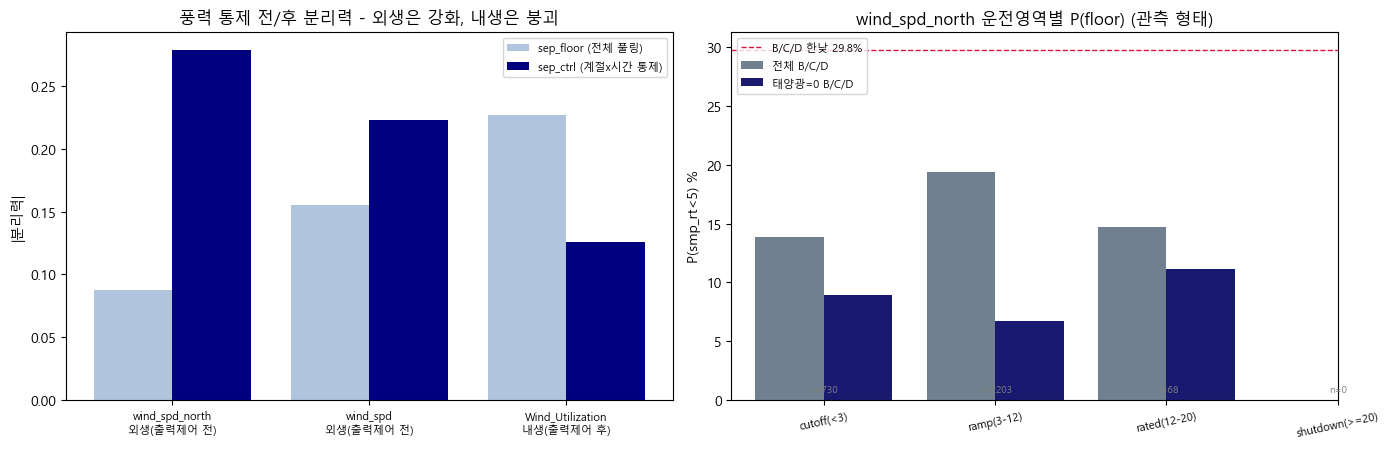

[Step 6] 풍력 = floor 출력제어 압력 축 - 외생 vs 내생 (+ 운전영역 검증)
                        kind  auc_floor  sep_floor  sep_ctrl     n
var                                                               
wind_spd_north    외생(출력제어 전)      0.544      0.088     0.279  3001
wind_spd          외생(출력제어 전)      0.578      0.155     0.223  3001
Wind_Utilization  내생(출력제어 후)      0.386      0.227     0.126  3001

[풍력 운전영역별 P(floor)]  (B/C/D)
  cutoff(<3)       n=  730  전체  13.84%  태양광=0   8.93%
  ramp(3-12)       n= 2203  전체  19.38%  태양광=0   6.70%
  rated(12-20)     n=   68  전체  14.71%  태양광=0  11.11%
  shutdown(>=20)   n=    0  전체    n/a  태양광=0    n/a

-> 내생(Wind_Utilization): sep_floor 큰데 통제 후 붕괴 = KPX 출력제어 사후 결과(원인 아님).
   외생(wind_spd_north): 풀링 약하나 통제 후 강화 = 출력제어 *전* 압력(억제변수, 진짜 원인).
   실측 P(floor) 형태: cutoff 13.8% -> ramp 19.4% -> rated 14.7%  (정점=ramp)
   ! 표본 부족 영역 ['shutdown(>=20)'] (wind_spd_north = 지표 평균 -> 컷아웃 20m/s 미도달)
     => rated/shutdown 의 단조 아님은 본 변수로 검증 불가. 풍력은 단조(고풍=floor↑) 신호로 취급.


In [8]:
W = []
for c in WIND_VARS:
    a, n = mw_auc(bcd[c], bcd['rt_neg'])
    W.append({'var':c,
              'kind':'외생(출력제어 전)' if c in EXO_WIND else '내생(출력제어 후)',
              'auc_floor':round(a,3), 'sep_floor':round(sep(a),3),
              'sep_ctrl':round(controlled_sep(bcd, c),3), 'n':n})
WS = pd.DataFrame(W).set_index('var')

# 풍력터빈 운전영역별 P(floor) - 단조 아님(rated 정점) 가설 검증.
#  태양광=0(밤·일사 0) 레짐은 floor 를 밀 신재생이 풍력뿐 -> 풍력 단독 효과.
reg_all = bcd.groupby('wind_reg', observed=True)['rt_neg'].mean().reindex(WIND_REG_LABELS) * 100
reg_n0  = (bcd[bcd['solar_rad'] <= 1.0]
           .groupby('wind_reg', observed=True)['rt_neg'].mean().reindex(WIND_REG_LABELS) * 100)
reg_cnt = bcd['wind_reg'].value_counts().reindex(WIND_REG_LABELS)
mid_floor = bcd[bcd['daypart']=='한낮']['rt_neg'].mean() * 100   # B/C/D 한낮 대조

fig, ax = plt.subplots(1, 2, figsize=(14, 4.6))
x = np.arange(len(WS))
ax[0].bar(x-0.2, WS['sep_floor'].values, 0.4, color='lightsteelblue', label='sep_floor (전체 풀링)')
ax[0].bar(x+0.2, WS['sep_ctrl'].values,  0.4, color='navy',           label='sep_ctrl (계절x시간 통제)')
ax[0].set_xticks(x)
ax[0].set_xticklabels([f'{i}\n{WS.loc[i,"kind"]}' for i in WS.index], fontsize=8)
ax[0].set_title('풍력 통제 전/후 분리력 - 외생은 강화, 내생은 붕괴')
ax[0].set_ylabel('|분리력|'); ax[0].legend(fontsize=8)

xr = np.arange(len(WIND_REG_LABELS))
ax[1].bar(xr-0.2, reg_all.values, 0.4, color='slategray',     label='전체 B/C/D')
ax[1].bar(xr+0.2, reg_n0.values,  0.4, color='midnightblue',  label='태양광=0 B/C/D')
ax[1].axhline(mid_floor, color='crimson', ls='--', lw=1, label=f'B/C/D 한낮 {mid_floor:.1f}%')
for i, r in enumerate(WIND_REG_LABELS):                       # 표본 수 주석 (희박 영역 경고용)
    c_ = reg_cnt[r]; ax[1].text(i, 0.5, f'n={int(c_) if pd.notna(c_) else 0}',
                                ha='center', va='bottom', fontsize=7, color='gray')
ax[1].set_xticks(xr); ax[1].set_xticklabels(WIND_REG_LABELS, rotation=12, fontsize=8)
ax[1].set_title(f'{BEST_WIND} 운전영역별 P(floor) (관측 형태)')
ax[1].set_ylabel('P(smp_rt<5) %'); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

order = reg_all.dropna()
peak  = order.idxmax().split('(')[0] if len(order) else 'n/a'
shape = ' -> '.join(f'{r.split("(")[0]} {order[r]:.1f}%' for r in order.index)
thin  = [r for r in WIND_REG_LABELS if pd.isna(reg_cnt[r]) or reg_cnt[r] < 50]
print('='*64)
print('[Step 6] 풍력 = floor 출력제어 압력 축 - 외생 vs 내생 (+ 운전영역 검증)')
print('='*64)
print(WS.to_string()); print()
print('[풍력 운전영역별 P(floor)]  (B/C/D)')
for r in WIND_REG_LABELS:
    a_, n_, c_ = reg_all[r], reg_n0[r], reg_cnt[r]
    sa = f'{a_:6.2f}%' if pd.notna(a_) else '   n/a'
    sn = f'{n_:6.2f}%' if pd.notna(n_) else '   n/a'
    print(f'  {r:16s} n={int(c_) if pd.notna(c_) else 0:5d}  전체 {sa}  태양광=0 {sn}')
print()
print('-> 내생(Wind_Utilization): sep_floor 큰데 통제 후 붕괴 = KPX 출력제어 사후 결과(원인 아님).')
print(f'   외생({BEST_WIND}): 풀링 약하나 통제 후 강화 = 출력제어 *전* 압력(억제변수, 진짜 원인).')
print(f'   실측 P(floor) 형태: {shape}  (정점={peak})')
if thin:
    print(f'   ! 표본 부족 영역 {thin} (wind_spd_north = 지표 평균 -> 컷아웃 20m/s 미도달)')
    print('     => rated/shutdown 의 단조 아님은 본 변수로 검증 불가. 풍력은 단조(고풍=floor↑) 신호로 취급.')
else:
    print('   => 단조 아님(rated 정점·shutdown 하락) 확인.')

## Step 7 - DA baseline 이 깨지는 곳 = Phase 6 결론 (미래 / 태양광 / 풍력)

**목표**: Phase 6 의 *모델링 직결 결론*. zone B/C/D 에서 `BEST_FUT`/`BEST_SOLAR`/`BEST_WIND`
zone내 분위별 `|gap|`·`gap std` 를 그려 DA(smp_jeju) 가 가장 못 믿을 축을 특정한다.
[A] 계절x시간 최악 셀(Phase 3/5 의 봄 한낮과 대조) + [B] 태양광=0 레짐의 풍력 운전영역별
DA 오차를 본다. DA *오차 크기* 의 주된 축이 무엇인지, 풍력이 floor *발생* 외에 DA *오차*
의 단독 축까지 되는지(되면 단조 아님·rated 정점, 표본 부족이면 보류) 를 데이터로 판정 =
Phase 6 hand-off.

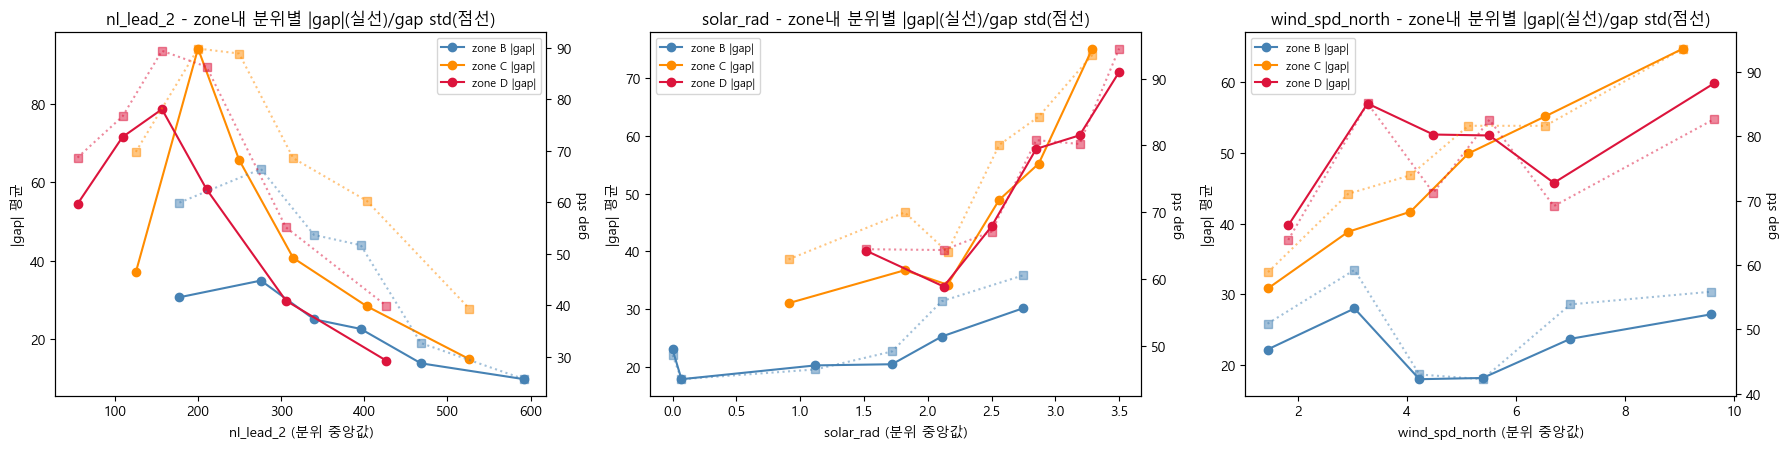

[Step 7] DA baseline 이 깨지는 곳 = Phase 6 결론 (zone B/C/D)
[A] gap std 최악 계절x시간 셀 Top6  (태양광+미래저점 축)
                  n  gap_abs  gap_std  p_floor
season daypart                                
봄      한낮       703    69.90    85.80     0.44
여름     한낮        85    43.14    72.42     0.19
봄      아침       205    40.36    66.98     0.17
겨울     한낮       326    35.60    64.20     0.19
봄      오후       495    27.56    56.17     0.11
가을     한낮       319    24.30    48.79     0.14

[B] 태양광=0 레짐 - 풍력 운전영역별 DA 오차  (풍력 출력제어 축)
                    n  gap_mean  gap_abs  p_floor
wind_reg                                         
cutoff(<3)       56.0     17.98    25.99     0.09
ramp(3-12)      627.0     10.63    19.68     0.07
rated(12-20)     18.0     12.64    19.36     0.11
shutdown(>=20)    NaN       NaN      NaN      NaN

-> [A] 압도적 DA 실패축 = 봄 한낮 (gap_std 86, p_floor 0.44) = 태양광+미래저점.
   [B] 태양광=0 풍력 운전영역 DA 오차: |gap| 단조증가 = False + rated/shutdown 표본 부족.
   => 풍력은 floor *발생*(Step5/6, 별개 축) 엔 기여하나, DA 

In [9]:
for col in [BEST_FUT, BEST_SOLAR, BEST_WIND]:
    if f'_qz_{col}' not in df.columns:
        df[f'_qz_{col}'] = zone_quantile(df, col, 6)

fig, ax = plt.subplots(1, 3, figsize=(18, 4.6))
for j, col in enumerate([BEST_FUT, BEST_SOLAR, BEST_WIND]):
    qz = f'_qz_{col}'
    a2 = ax[j]; a3 = a2.twinx()
    for z, cc in zip(ZBCD, ['steelblue','darkorange','crimson']):
        s = df[(df['zone']==z) & df[qz].notna()]
        gg = s.groupby(qz)
        a2.plot(gg[col].median().values, gg['gap'].apply(lambda x: x.abs().mean()).values,
                'o-', color=cc, label=f'zone {z} |gap|')
        a3.plot(gg[col].median().values, gg['gap'].std().values, 's:', color=cc, alpha=0.5)
    a2.set_title(f'{col} - zone내 분위별 |gap|(실선)/gap std(점선)')
    a2.set_xlabel(f'{col} (분위 중앙값)'); a2.set_ylabel('|gap| 평균'); a3.set_ylabel('gap std')
    a2.legend(fontsize=8)
plt.tight_layout(); plt.show()

# (1) DA 가 가장 안 맞는 계절x시간 = Phase 3/5 기준값 (봄 한낮)
worst = (df[df['zone'].isin(ZBCD)]
         .groupby(['season','daypart'], observed=True)
         .agg(n=('gap','size'), gap_abs=('gap', lambda s: s.abs().mean()),
              gap_std=('gap','std'), p_floor=('rt_neg','mean'))
         .sort_values('gap_std', ascending=False).head(6).round(2))

# (2) 태양광=0 레짐: DA 오차가 풍력 운전영역을 따라 단조가 아닌가 (rated 정점이면 풍력이 일으킨 DA 실패)
n0 = df[df['zone'].isin(ZBCD) & (df['solar_rad'] <= 1.0)].copy()
wgap = (n0.groupby('wind_reg', observed=True)
          .agg(n=('gap','size'), gap_mean=('gap','mean'),
               gap_abs=('gap', lambda s: s.abs().mean()),
               p_floor=('rt_neg','mean'))
          .reindex(WIND_REG_LABELS).round(2))

top_cell = worst.index[0]
wg = wgap.dropna(subset=['gap_abs'])
wind_da_monotone = bool(len(wg) >= 3 and wg['gap_abs'].is_monotonic_increasing)
print('='*64)
print('[Step 7] DA baseline 이 깨지는 곳 = Phase 6 결론 (zone B/C/D)')
print('='*64)
print('[A] gap std 최악 계절x시간 셀 Top6  (태양광+미래저점 축)')
print(worst.to_string()); print()
print('[B] 태양광=0 레짐 - 풍력 운전영역별 DA 오차  (풍력 출력제어 축)')
print(wgap.to_string()); print()
print(f'-> [A] 압도적 DA 실패축 = {top_cell[0]} {top_cell[1]} '
      f'(gap_std {worst.iloc[0]["gap_std"]:.0f}, p_floor {worst.iloc[0]["p_floor"]:.2f}) = 태양광+미래저점.')
print(f'   [B] 태양광=0 풍력 운전영역 DA 오차: |gap| 단조증가 = {wind_da_monotone} '
      f'+ rated/shutdown 표본 부족.')
print('   => 풍력은 floor *발생*(Step5/6, 별개 축) 엔 기여하나, DA *오차 크기* 의 단독 축은 아님.')
print('   => 보정/분리모델 1순위 = 봄 한낮(태양광/미래). 풍력은 occurrence 피처로 합류.')

## Step 8 - Phase 6 종합 / 모델링 hand-off

**목표**: Step 0-7 의 핵심 수치를 한 블록으로 모아 `report.ipynb` Phase 6 digest 로
그대로 옮긴다. leakage 주의(미래 net_load = 설명용, 모델은 forecast 대체 필요) 명시.

In [10]:
print('='*64)
print('[Step 8] Phase 6 종합 / 결론 - report.ipynb digest (아래 그대로 복사)')
print('='*64)
try:
    bestE   = max(e_all, e_allreg)
    bestGrp = '3분위(단조)' if e_all >= e_allreg else '운전영역(단조 아님)'
    print(f'1) 미래 net_load: 최강 = {BEST_FUT} (통제분리력 {S2.loc[BEST_FUT,"sep_BCD_ctrl"]:.3f}) '
          f'vs 현재 net_load {S2.loc["net_load","sep_BCD_ctrl"]:.3f} -> 미래 우위')
    print(f'2) 태양광: 최강 = {BEST_SOLAR} (통제분리력 {S4.loc[BEST_SOLAR,"sep_BCD_ctrl"]:.3f}) '
          f'-> floor 는 태양광 현상(Phase5 재확인)')
    print(f'3) 결합 설명력(B/C/D, eta^2): net_load {e_zone*100:.1f}% -> +미래 {e_lead*100:.1f}% '
          f'/ +태양광 {e_solar*100:.1f}% / +미래+태양광 {e_fs*100:.1f}% '
          f'/ +풍력 {bestE*100:.1f}% (잔여의 {(bestE-e_zone)/(1-e_zone)*100:.1f}% 추가 설명)')
    print(f'   풍력 조건부 증분: 3분위 {(e_all-e_fs)*100:+.1f}%p vs 운전영역 {(e_allreg-e_fs)*100:+.1f}%p '
          f'-> 채택 = {bestGrp}')
    print(f'4) 풍력 = 별개 floor 축(출력제어 압력): 외생 {BEST_WIND} sep_ctrl {WS.loc[BEST_WIND,"sep_ctrl"]:.3f} '
          f'(풀링 {WS.loc[BEST_WIND,"sep_floor"]:.3f} -> 통제 후 강화 = 진짜 원인),')
    print('   내생 Wind_Utilization 통제 후 붕괴 = KPX 출력제어 사후 결과(사후량은 원인 아님).')
    print('   * 터빈 운전영역 단조 아님(rated 정점/shutdown 하락) 가설: shutdown(>=20) 표본 0,')
    print('     rated(12-20) 희박 -> wind_spd_north 는 지표 평균이라 컷아웃 미도달 = 검증 불가.')
    print('     풍력은 zone내 단조(고풍=floor↑) 신호로 채택 (허브높이/실측출력 확보 시 재검토).')
    print('   태양광=분산형(출력제어 대상 아님, 직접 가격압박) vs 풍력=출력제어 압력(대형·KPX제어) = 별개 두 축.')
    print('5) 급전순위 merit order(도메인): floor = renew+HVDC+oil 필수운전(~80MW) >= demand 시')
    print('   LNG 정지, 가격이 oil 최저 입찰가(~0) 로 붕괴. floor 경계 = LNG<->oil 전환 = net_load 임계.')
    print('   -> zone 구조 + 미래/forward-trough 우위가 이 임계의 자연스러운 결과.')
    print('6) [결론] DA(smp_jeju) 가 깨지는 곳:')
    print('   주된 축 = 봄 한낮 (gap_std 최대·p_floor 최고) = 태양광+미래저점.')
    print('   풍력은 floor *발생* 설명엔 기여(별개 축)하나, 태양광=0 에서 DA *오차 크기* 의')
    print('   단독 축으로는 약함 -> 보정 1순위는 봄 한낮.')
    print('7) leakage: nl_lead_*/nl_fwdmin_* 는 실현 미래(예측시 미지) = 설명 전용.')
    print('   모델은 est_demand + 신재생 forecast 로 만든 forecast-net_load 로 대체 필요.')
    print()
    print('[모델링 hand-off]  (Phase 6 종료 -> 모델링 단계)')
    print(' - baseline=DA(smp_jeju) + zone/net_load 보정 위에, zone내 상호작용항')
    print(f'   (미래net_load 3분위 x {BEST_SOLAR} 3분위 x {BEST_WIND} 3분위[단조]) 추가.')
    print('   zone B/C/D 한정(A 는 passthrough). 풍력은 실현발전량(출력제어 후) 말고')
    print('   북부 풍속(출력제어 전) 사용. 운전영역(단조 아님)은 허브높이/실측출력 확보 시 재검토.')
    print(' - floor 는 occurrence 분류기 + level 회귀 분리(Phase 5 와 동일 권고).')
    print(' - 보정 우선순위: (1) 봄 한낮 태양광/미래저점, (2) 고풍 풍력(occurrence 피처).')
except NameError as e:
    print(f'(미정의 변수: {e}) -> Step 2~7 을 위에서부터 순서대로 실행한 뒤 다시 실행하세요.')

[Step 8] Phase 6 종합 / 결론 - report.ipynb digest (아래 그대로 복사)
1) 미래 net_load: 최강 = nl_lead_2 (통제분리력 0.455) vs 현재 net_load 0.334 -> 미래 우위
2) 태양광: 최강 = solar_rad (통제분리력 0.315) -> floor 는 태양광 현상(Phase5 재확인)
3) 결합 설명력(B/C/D, eta^2): net_load 8.4% -> +미래 18.2% / +태양광 11.9% / +미래+태양광 23.1% / +풍력 26.8% (잔여의 20.1% 추가 설명)
   풍력 조건부 증분: 3분위 +3.6%p vs 운전영역 +2.7%p -> 채택 = 3분위(단조)
4) 풍력 = 별개 floor 축(출력제어 압력): 외생 wind_spd_north sep_ctrl 0.279 (풀링 0.088 -> 통제 후 강화 = 진짜 원인),
   내생 Wind_Utilization 통제 후 붕괴 = KPX 출력제어 사후 결과(사후량은 원인 아님).
   * 터빈 운전영역 단조 아님(rated 정점/shutdown 하락) 가설: shutdown(>=20) 표본 0,
     rated(12-20) 희박 -> wind_spd_north 는 지표 평균이라 컷아웃 미도달 = 검증 불가.
     풍력은 zone내 단조(고풍=floor↑) 신호로 채택 (허브높이/실측출력 확보 시 재검토).
   태양광=분산형(출력제어 대상 아님, 직접 가격압박) vs 풍력=출력제어 압력(대형·KPX제어) = 별개 두 축.
5) 급전순위 merit order(도메인): floor = renew+HVDC+oil 필수운전(~80MW) >= demand 시
   LNG 정지, 가격이 oil 최저 입찰가(~0) 로 붕괴. floor 경계 = LNG<->oil 전환 = net_load 임계.
   -> zone 구조 + 미래/forward-trough 우위가 이 임계의 자연스러운 결과.
6) [결론] DA(smp_jeju)